## Detección de cambio semántico - dinámico


Para controlar la visualizacion usar:
* https://www.color-blindness.com/coblis-color-blindness-simulator/
* https://colorbrewer2.org/#type=diverging&scheme=BrBG&n=3

In [1]:
# Cargar las librerías necesarias
from dotenv import load_dotenv
import pandas as pd
import pickle 
import os
import sys
import numpy as np
from scipy import stats
import ast

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
load_dotenv() 

True

In [2]:
HEALTH_CYAN = "#0077A8"   # celeste medio
GRAY_MAIN   = "#8F8F8F"
GRAY_LIGHT  = "#E0E0E0"
GRAY_DARK   = "#3A3A3A"

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import locale
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

locale.setlocale(locale.LC_ALL, 'es_AR.UTF-8')
#'es_ES.UTF-8'
#'es_ES'
#'spanish'

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette=[HEALTH_CYAN, GRAY_MAIN, GRAY_LIGHT, GRAY_DARK]
)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "font.size": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.edgecolor": "#2B2B2B",
    "axes.labelcolor": "#2B2B2B",
    "text.color": "#2B2B2B",
    "grid.color": "#E5E5E5",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "legend.fontsize": 18,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})


### Lectura de datos


In [4]:
# Configurar path
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
IMAG_DIR = BASE_DIR+'imagenes/'
sys.path.append(BASE_DIR)
modelo_dir =  RESULTADOS_DIR+ '/archivos_out/modelos_swmwosge_5051100'
pd.set_option('display.max_colwidth', None)

In [5]:
df_concat = pd.read_csv(RESULTADOS_DIR+"archivos_out/EMBEDDINGCONTEX_ALL.csv")   


In [6]:
df_concat.head(3)

,Unnamed: 0,palabra,periodo,JS_divergence,APD_cosine,APD_canberra,APD_euclidean,cluster_distribucion_1,cluster_distribucion_2,cantidad_1,cantidad_2,silhouette_score
0,0,ochenta,2009-2014,0.045407,0.043514,224.948111,72.131837,[0.875 0.125],[1. 0.],8,8,0.383930
1,1,san,2009-2014,0.256816,0.101740,325.600657,116.127967,[0.14285714 0.28571429 0.28571429 0.28571429],[0.33333333 0.66666667 0. 0. ],7,3,0.114425
2,2,ciento,2009-2014,0.040143,0.068414,244.798078,85.280661,[0.88888889 0.11111111],[1. 0.],9,9,0.486660


In [7]:

def mostrar_metrica(m1,m2,basemetrica1):
    # Test estadístico para diferencia de distribuciones
    t_stat, p_value = stats.ttest_ind(m1, m2)
    
    print("ANÁLISIS ESTADÍSTICO DE "+basemetrica1.upper())
    print(f"2009 - 2014: Media = {m1.mean():.3f} ± {m1.std():.3f}")
    print(f"2014 - 2019: Media = {m2.mean():.3f} ± {m2.std():.3f}")
    print(f"Diferencia: {m1.mean() - m2.mean():.3f}")
    print(f"Test t: t = {t_stat:.3f}, p-value = {p_value:.3f}")
    print(f"Significativo (p < 0.05): {'SÍ' if p_value < 0.05 else 'NO'}")


def visualizacion_metrica_enfoque(metrica_df,metrica, basemetrica,metrica_2009_2014,metrica_2014_2019):
    

    # Paleta optimizada para similitud coseno
    PALETA_COSENO = {
        '2009-2014': '#253494',  # azul oscuro
        '2014-2019': '#D95F0E'    # naranja intenso
    }
    
    
    plt.figure(figsize=(14, 10))
    # Gráfico principal
    sns.kdeplot(
        data=metrica_df,
        x=metrica,
        hue='periodo',
        palette=PALETA_COSENO,
        fill=True,
        alpha=0.3,
        common_norm=False
    )
    
    plt.xlabel(basemetrica.capitalize(), fontsize=14, fontweight='bold')
    plt.ylabel('Densidad', fontsize=14, fontweight='bold')
    #plt.title('Distribución de densidad de promedio de similitud coseno', fontsize=14, fontweight='bold')
    
    
    # Calcular medias
    media_2009_2014 = metrica_2009_2014.mean()
    media_2014_2019 = metrica_2014_2019.mean()
    diferencia_medias = abs(media_2009_2014 - media_2014_2019)
    
    # Elementos visuales clave
    plt.axvline(media_2009_2014, color=PALETA_COSENO['2009-2014'], linestyle='--', linewidth=3, alpha=0.8)
    plt.axvline(media_2014_2019, color=PALETA_COSENO['2014-2019'], linestyle='--', linewidth=3, alpha=0.8)
    plt.axvspan(min(media_2009_2014, media_2014_2019), max(media_2009_2014, media_2014_2019), 
                alpha=0.2, color='gray')
    
    
    legend_elements = [
        Patch(facecolor=PALETA_COSENO['2009-2014'], alpha=0.5, label='2009-2014'),
        Patch(facecolor=PALETA_COSENO['2014-2019'], alpha=0.5, label='2014-2019'),
        plt.Line2D([0], [0], color=PALETA_COSENO['2009-2014'], linestyle='--', linewidth=2, 
                   label=f"Media 09-14: {locale.format_string('%.2f', media_2009_2014)}"),
        plt.Line2D([0], [0], color=PALETA_COSENO['2014-2019'], linestyle='--', linewidth=2, 
                   label=f"Media 14-19: {locale.format_string('%.2f', media_2014_2019)}"),
         Patch(facecolor='gray', alpha=0.2, label=f"Δ = {locale.format_string('%.2f', diferencia_medias)}")
     
    ]
    
    plt.legend(handles=legend_elements, loc='best', frameon=False, shadow=True)
    
    # Spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    
    
    formatter = FuncFormatter(lambda x, pos: locale.format_string('%.2f', x))
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)
    plt.grid(False)
    
    plt.tight_layout(pad=3)
    plt.savefig(BASE_DIR+'imagenes/'+basemetrica+'.png', 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

ANÁLISIS ESTADÍSTICO DE DIVERGENCIA DE JENSEN - SHANNON (JSD)
2009 - 2014: Media = 0.381 ± 0.175
2014 - 2019: Media = 0.412 ± 0.181
Diferencia: -0.031
Test t: t = -2.063, p-value = 0.040
Significativo (p < 0.05): SÍ


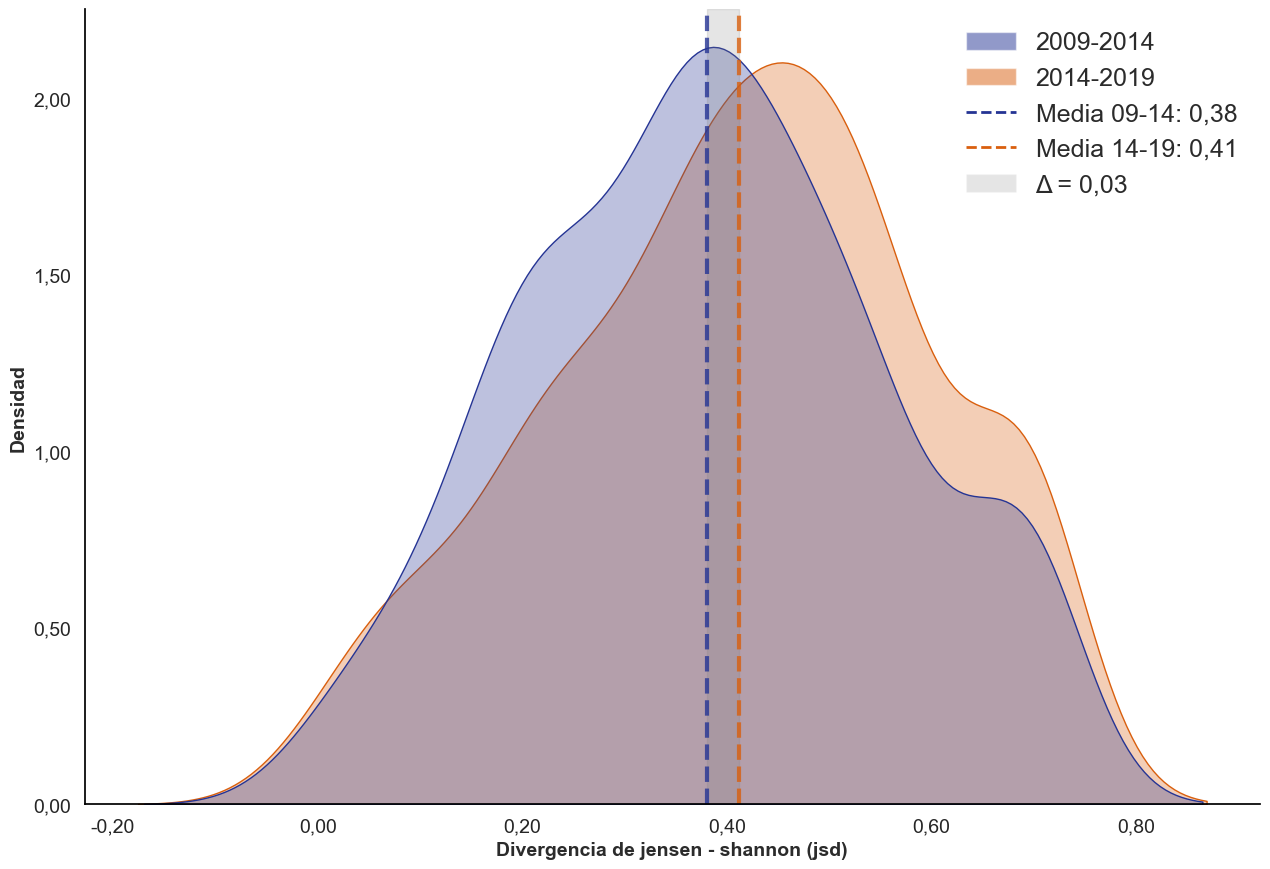

In [8]:
metrica_2009_2014_1 = df_concat[df_concat['periodo']=='2009-2014']['JS_divergence']
metrica_2014_2019_1 = df_concat[df_concat['periodo']=='2014-2019']['JS_divergence']
basemetrica=  'Divergencia de Jensen - Shannon (JSD)'
mostrar_metrica(metrica_2009_2014_1,metrica_2014_2019_1,basemetrica)
visualizacion_metrica_enfoque(df_concat,'JS_divergence',basemetrica,metrica_2009_2014_1,metrica_2014_2019_1)


In [9]:
def create_default_value():
    return 0
    

C:\Users\Usuario\AppData\Local\Temp\ipykernel_1672\3283186496.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


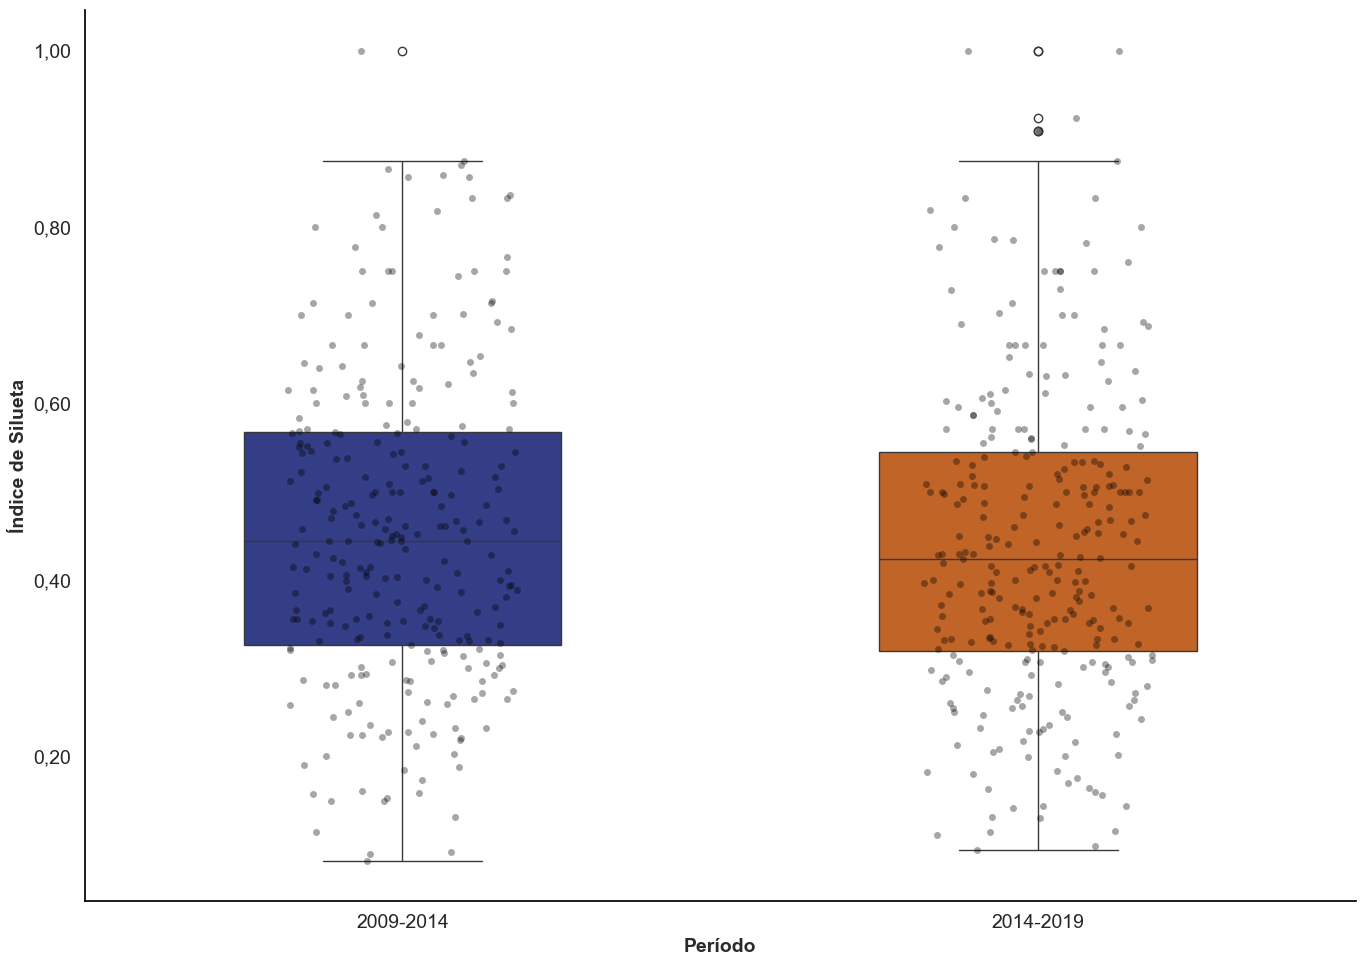

In [10]:
PALETA_score = {
        '2009-2014': '#253494',  # azul oscuro
        '2014-2019': '#D95F0E'    # naranja intenso
    }

plt.figure(figsize=(14, 10))

sns.boxplot(
    data=df_concat,
    x="periodo",
    y="silhouette_score",
    palette=PALETA_score,
    width=0.5,
    showfliers=True  # Si querés ocultar outliers → False
)

sns.stripplot(
    data=df_concat,
    x="periodo",
    y="silhouette_score",
    color='black',
    alpha=0.35,
    jitter=0.18
)

#plt.title("Comparación del índice de silueta por período", fontsize=14, fontweight='bold')
plt.xlabel("Período", fontsize=14, fontweight='bold')
plt.ylabel("Índice de Silueta", fontsize=14, fontweight='bold')

# Spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)
ax.set_facecolor('white')
plt.grid(False)
formatter = FuncFormatter(lambda x, pos: locale.format_string('%.2f', x))
ax.yaxis.set_major_formatter(formatter)

plt.tight_layout()

plt.savefig(BASE_DIR + "imagenes/Boxplot_silueta.png",
            dpi=300, bbox_inches="tight", facecolor='white')

plt.show()



In [11]:
def plot_temporal_distribution(word, word_data, decades):
    """
    Visualiza la distribución temporal de clusters para una palabra
    Similar a: https://github.com/glnmario/cwr4lsc/blob/master/clustering.py#L123
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Datos para el gráfico
    distributions = []
    counts = []
    periods = []
    
    for decade in decades:
        if decade in word_data:
            distributions.append(word_data[decade]['distribucion'])
            counts.append(word_data[decade]['ocurrencia'])
            periods.append(str(decade))
    
    if not distributions:
        return fig
    
    distributions = np.array(distributions)
    k = len(distributions[0])
    
    # Gráfico de distribución de clusters
    #colors = plt.cm.Set3(np.linspace(0, 1, k))
    #colors = plt.cm.cividis(np.linspace(0, 1, k))

    
    bottom = np.zeros(len(periods))
    
    for i in range(k):
        ax1.bar(periods, distributions[:, i], bottom=bottom, 
                label=f'Cluster {i}', alpha=0.8, color=colors[i])
        bottom += distributions[:, i]
    
    ax1.set_ylabel('Proporción de clusters')
    ax1.set_title(f'Distribución temporal de clusters - {word.upper()}')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Gráfico de conteo de usos
    ax2.bar(periods, counts, alpha=0.7, color='skyblue')
    ax2.set_ylabel('Número de usos')
    ax2.set_xlabel('Período')
    ax2.set_title(f'Frecuencia de uso por período - {word.upper()}')
    ax2.grid(True, alpha=0.3)
    
    # Añadir valores en las barras
    for i, count in enumerate(counts):
        ax2.text(i, count + max(counts)*0.01, str(count), 
                ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    return fig

def is_dark(color):
    r, g, b, _ = color  # RGBA
    # Fórmula estándar de luminancia perceptual
    luminance = 0.299*r + 0.587*g + 0.114*b
    return luminance < 0.5

def plot_word_clusters(df, inicio, fin, word,cantidad_inicio,cantidad_fin ):
    
    data = df[df["palabra"] == word].sort_values("numero_cluster")
    
    if data.empty:
        print("Palabra no encontrada")
        return
    
    clusters = data["numero_cluster"].values
    dist_inicio = data["periodo_"+str(inicio)].values
    dist_fin = data["periodo_"+str(fin)].values
    
    k = len(clusters)
    #colors = plt.cm.Set2(np.linspace(0, 1, k))
    #colors = plt.get_cmap("tab20")(np.linspace(0, 1, k))
    cmap = plt.get_cmap("viridis")  # mejor que viridis para accesibilidad
    colors = cmap(np.linspace(0, 1, k))
    #colors = plt.cm.viridis(np.linspace(0, 1, k)) # cividis
    
    fig, ax = plt.subplots(figsize=(14, 8), facecolor="white")
    ax.set_facecolor("white")
    
    x = np.arange(2)  # dos periodos
    width = 0.6
    bottom = np.zeros(2)
    
    for i in range(k):
        values = [dist_inicio[i], dist_fin[i]]
        ax.bar(x, values, width, bottom=bottom,
               label=f"Cluster {clusters[i]}",
               color=colors[i])
                # 🔹 Añadir etiquetas de proporción
        for j in range(2):
            if values[j] > 0.02:  # evitar texto en barras muy pequeñas

                text_color = "white" if is_dark(colors[i]) else "black"

                ax.text(
                    x[j],
                    bottom[j] + values[j]/2,
                    locale.format_string('%.2f', values[j]),
                    ha='center',
                    va='center',
                    fontsize=18,
                    color=text_color,
                    fontweight='bold'
                )
        
        bottom += values
    

    ax.set_xticks(x)
    ax.set_xticklabels([
        f"{inicio}\n(n={cantidad_inicio})",
        f"{fin}\n(n={cantidad_fin})"
    ])

    # Spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=14)
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    
    formatter = FuncFormatter(lambda x, pos: locale.format_string('%.2f', x))
    ax.yaxis.set_major_formatter(formatter)
    
    ax.set_ylabel("Proporción de clusters")
    #ax.set_title(f"Distribución de clusters – {word.upper()}")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left",frameon=False)
    ax.grid(False)
    
    plt.tight_layout()
    plt.savefig(IMAG_DIR+f'barra_{word}.png', dpi=300, bbox_inches='tight')
    plt.show()


In [12]:
#Ejemplo
embedding_cluster_df = pd.read_csv(RESULTADOS_DIR+ '/archivos_out/EMBEDDING__Clustering2009_2014.csv')
embedding_cluster_df.head(4)

,palabra,numero_cluster,periodo_2009,periodo_2014,ejemplos
0,ochenta,0,0.875000,1.000000,(desconocido): plazo ciento ochenta corrido prorrogable | (desconocido): termino ciento ochenta prorrogable distrito | (desconocido): plazo ciento ochenta prorrogable diverso | (desconocido): plazo ciento ochenta prorrogable diverso | (desconocido): plazo ciento ochenta prorrogable diverso
1,ochenta,1,0.125000,0.000000,(desconocido): nacional ciento ochenta
2,san,0,0.142857,0.333333,(desconocido): provincia mendoza san rafael general | (desconocido): jachal provincia san juan consecuencia
3,san,1,0.285714,0.666667,(desconocido): departamento provincia san juan afectado | (desconocido): departamento provincia san luis cordoba | (desconocido): localidad libertador san martin provincia | (desconocido): departamento provincia san luis declarar


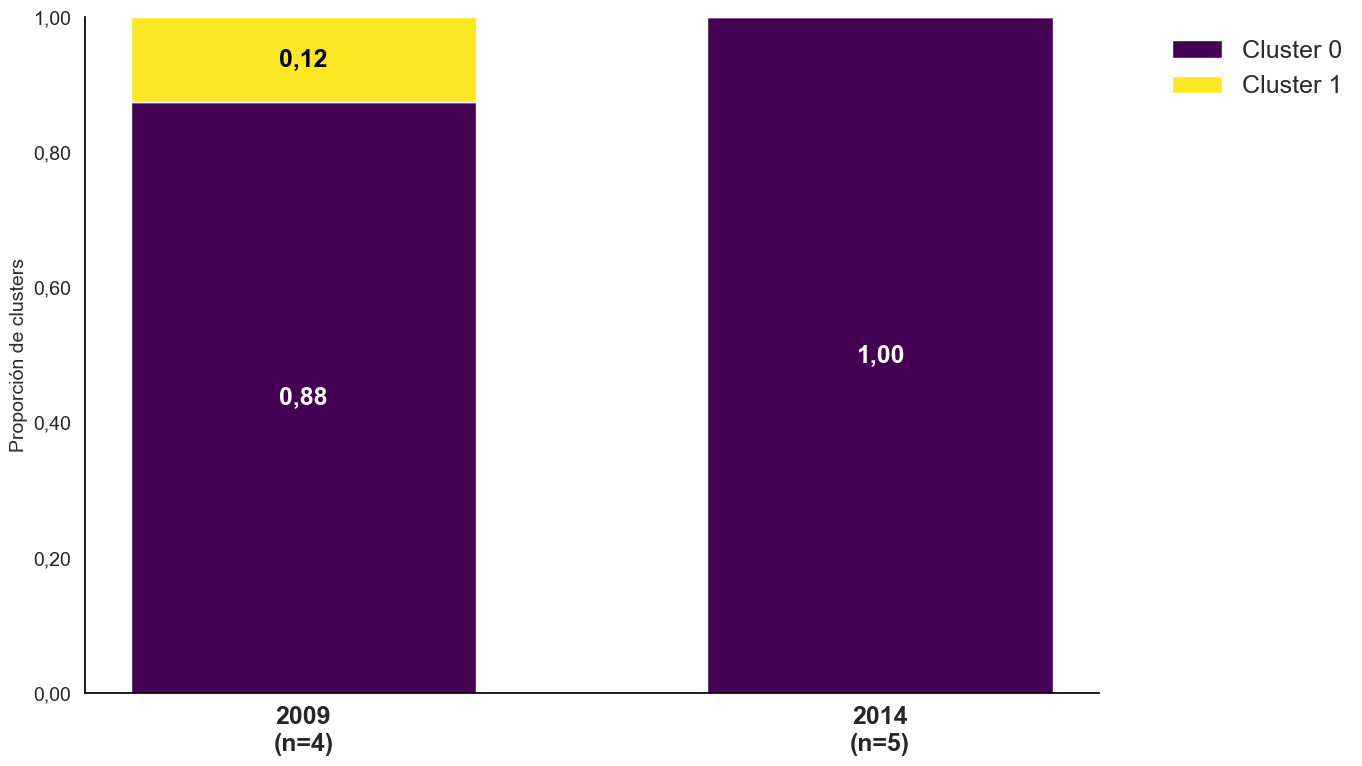

In [13]:
plot_word_clusters(embedding_cluster_df,'2009','2014', "ochenta",4,5)


,palabra,periodo,JS_divergence,silhouette_score,cantidad_1,cantidad_2
242,virus,2009-2014,0.693147,0.319347,10,5
222,recurso,2009-2014,0.693147,0.496618,7,2
260,publica,2009-2014,0.693147,0.434837,1,11
135,marzo,2009-2014,0.693147,0.444444,3,6
140,correspondiente,2009-2014,0.693147,0.456290,5,2
194,comunitario,2009-2014,0.693147,0.444444,6,3
171,respuesta,2009-2014,0.693147,0.148970,1,5
255,ganancia,2009-2014,0.693147,0.160863,4,1
153,trasplante,2009-2014,0.693147,0.750000,7,1
149,consejo,2009-2014,0.693147,0.444444,5,4


,palabra,periodo,JS_divergence,silhouette_score,cantidad_1,cantidad_2
260,publica,2009-2014,0.693147,0.434837,1,11
222,recurso,2009-2014,0.693147,0.496618,7,2
264,legal,2009-2014,0.693147,0.405982,2,6
247,receta,2009-2014,0.693147,0.545943,3,10
194,comunitario,2009-2014,0.693147,0.444444,6,3
55,parto,2009-2014,0.693147,0.500000,5,1
184,etiqueta,2009-2014,0.693147,0.428571,2,5
140,correspondiente,2009-2014,0.693147,0.456290,5,2
238,consentimiento,2009-2014,0.693147,0.420394,4,8
36,personal,2009-2014,0.693147,0.461538,2,11


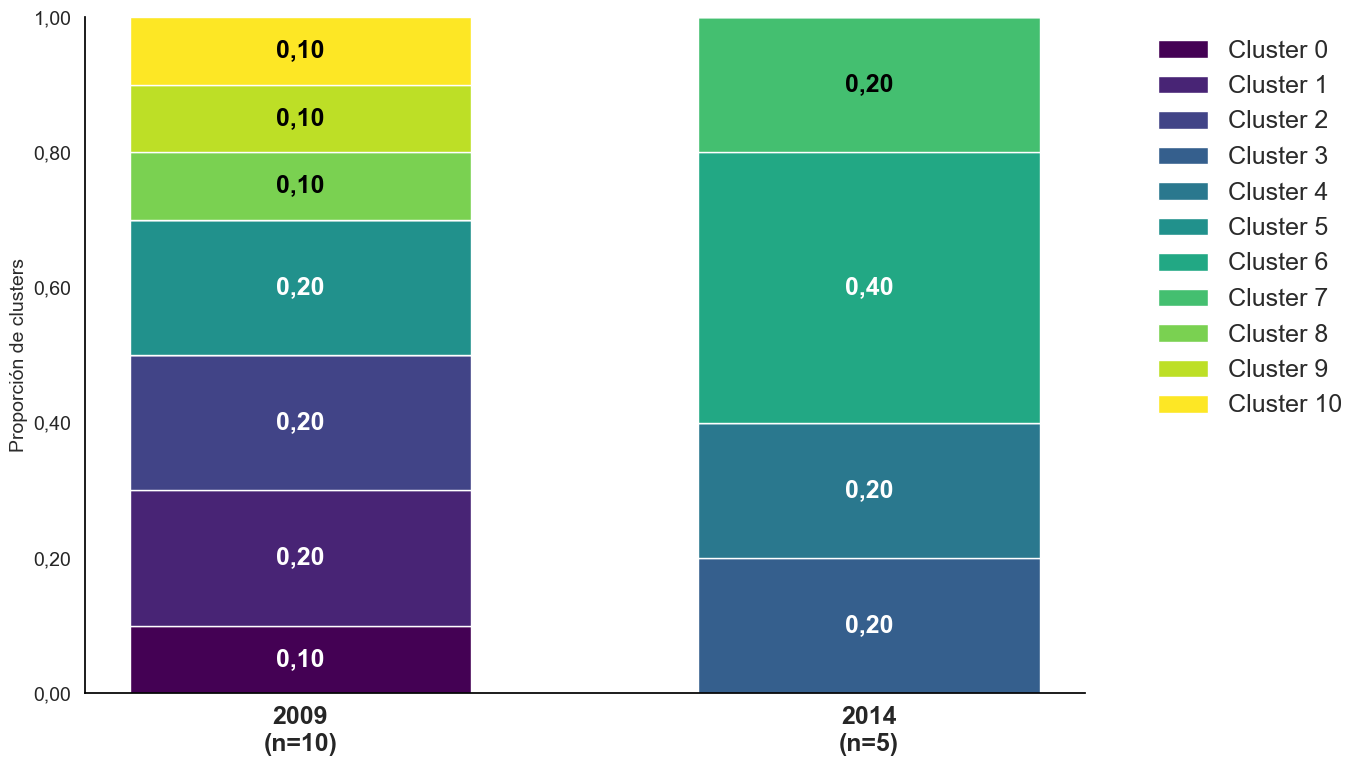

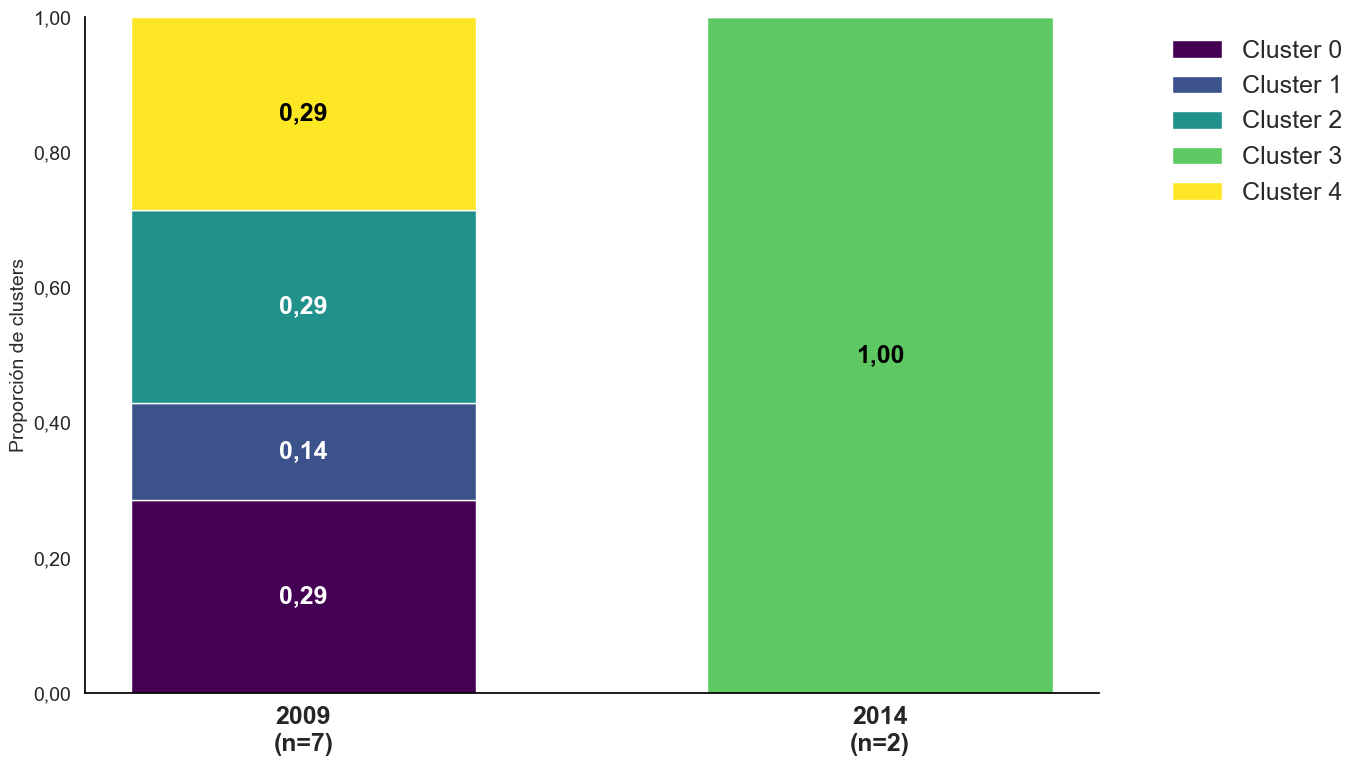

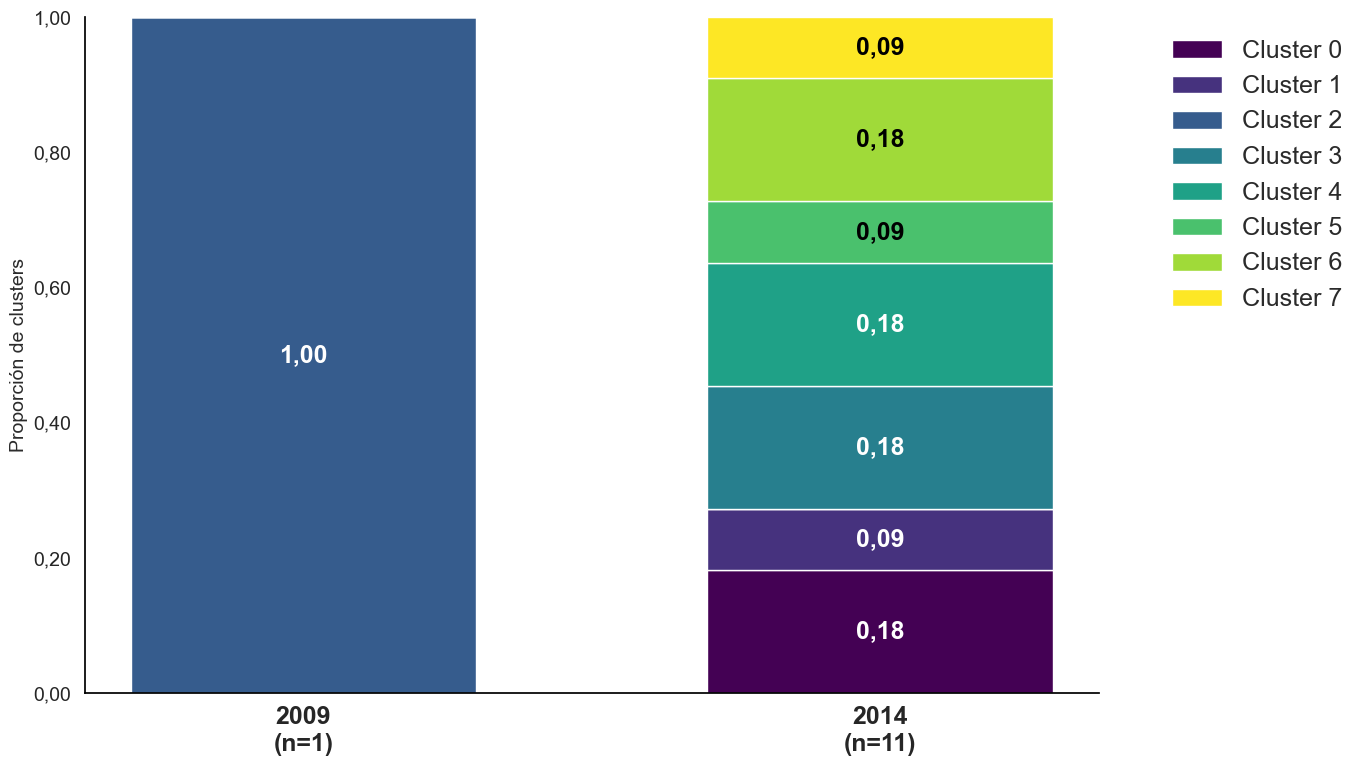

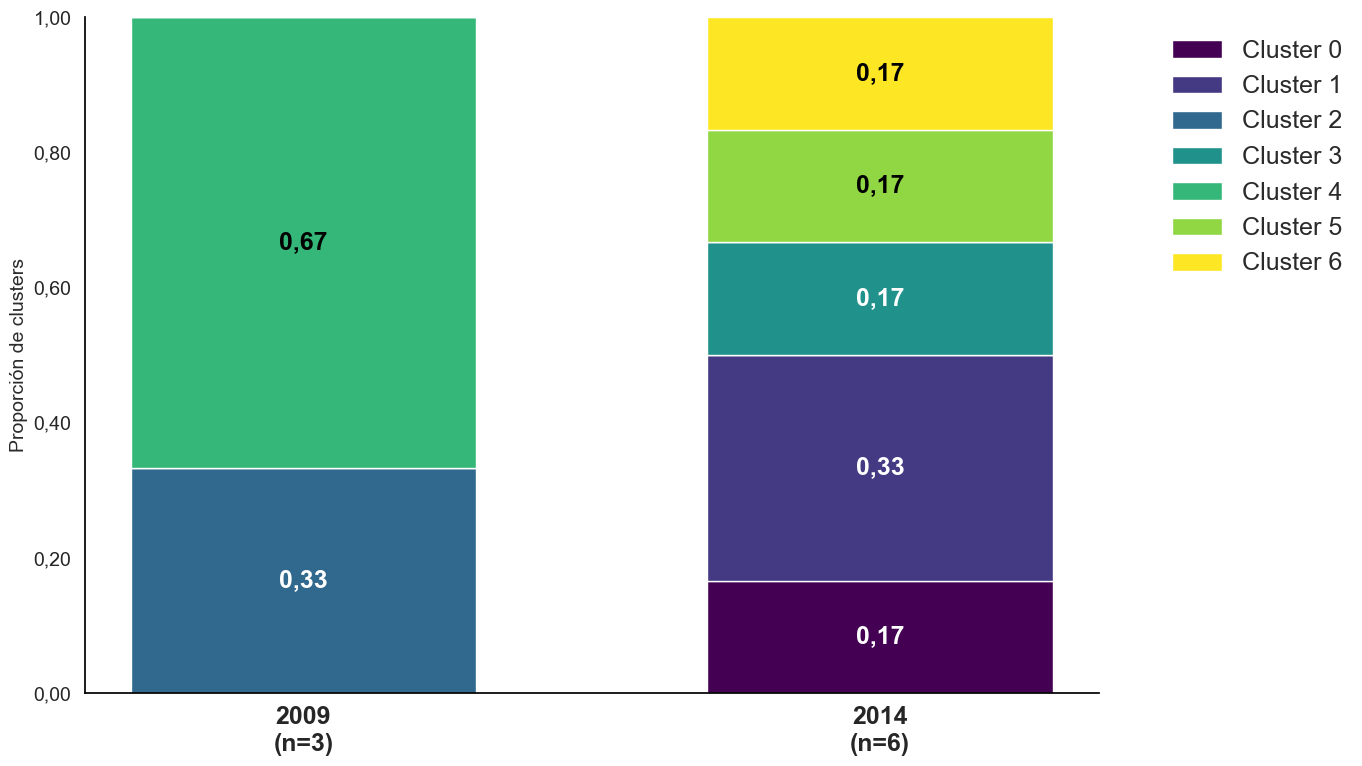

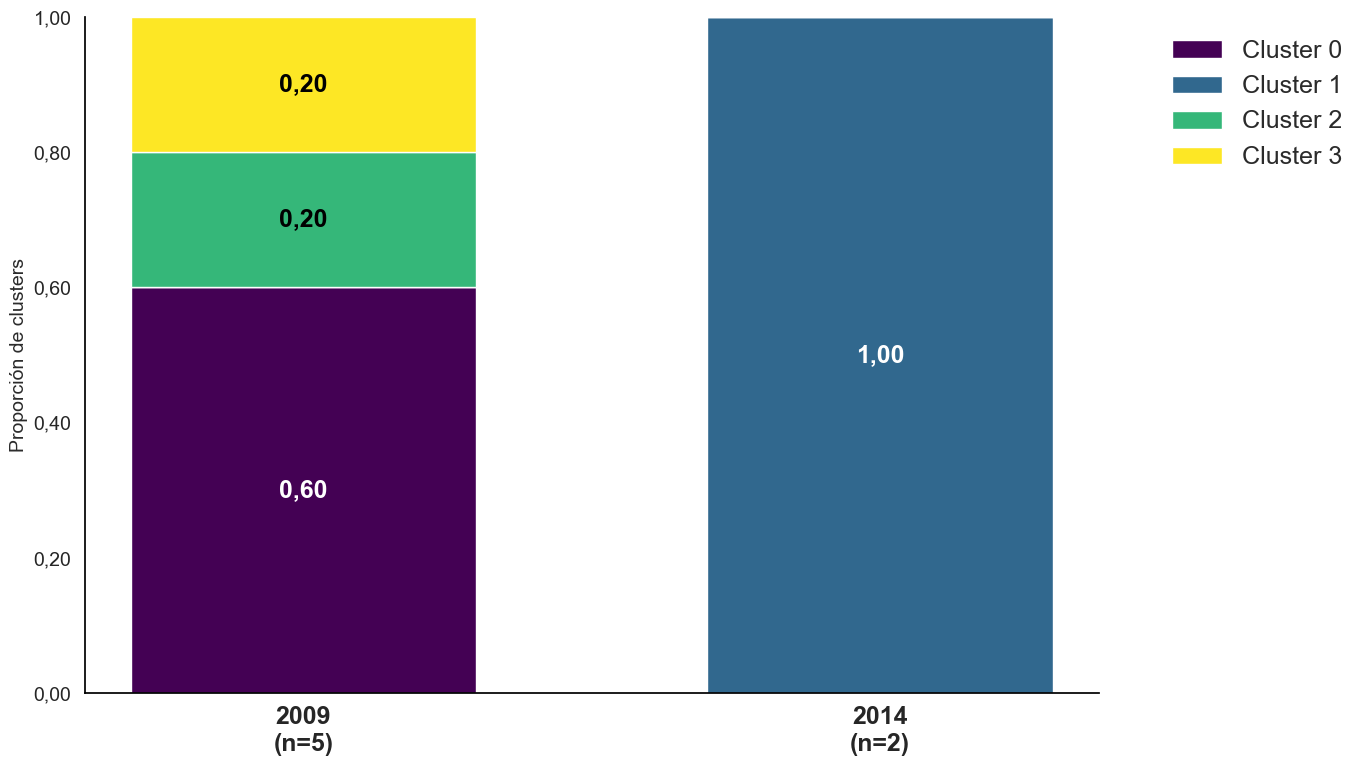

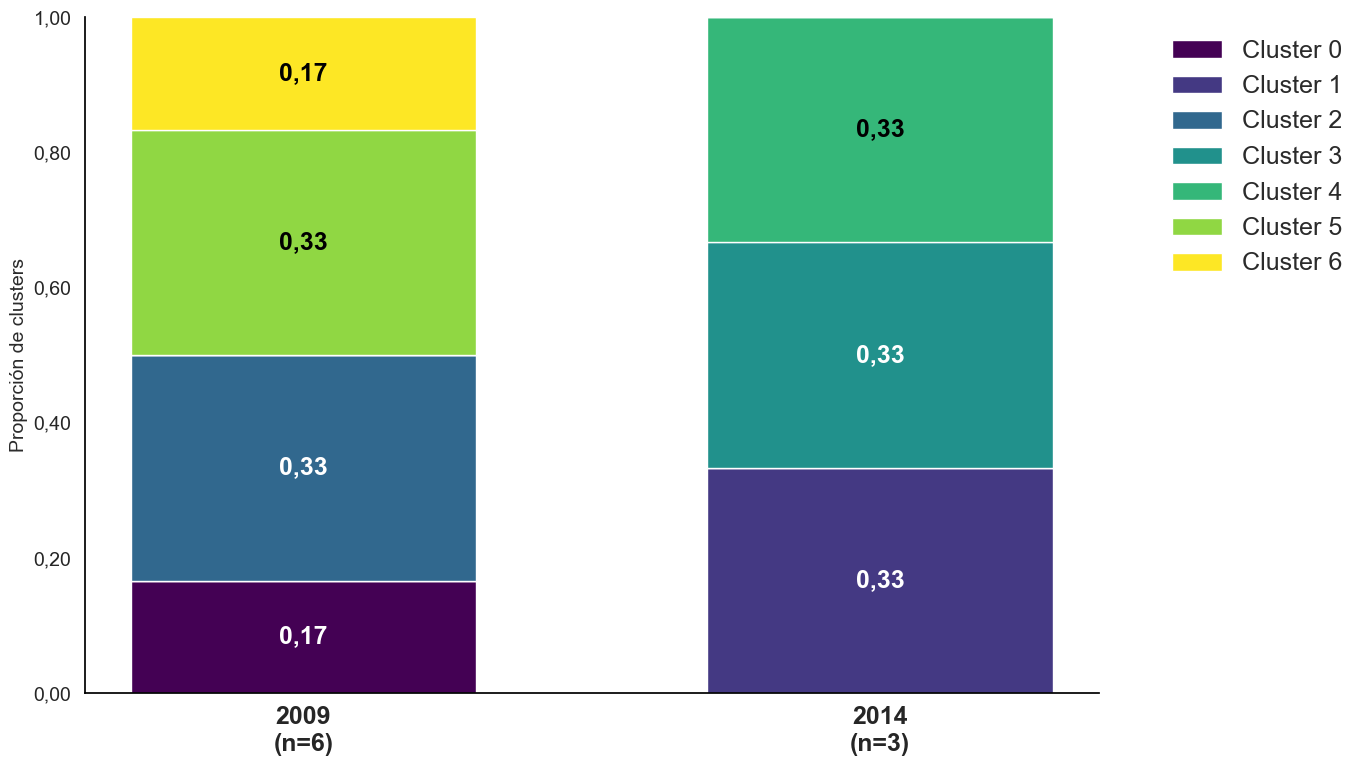

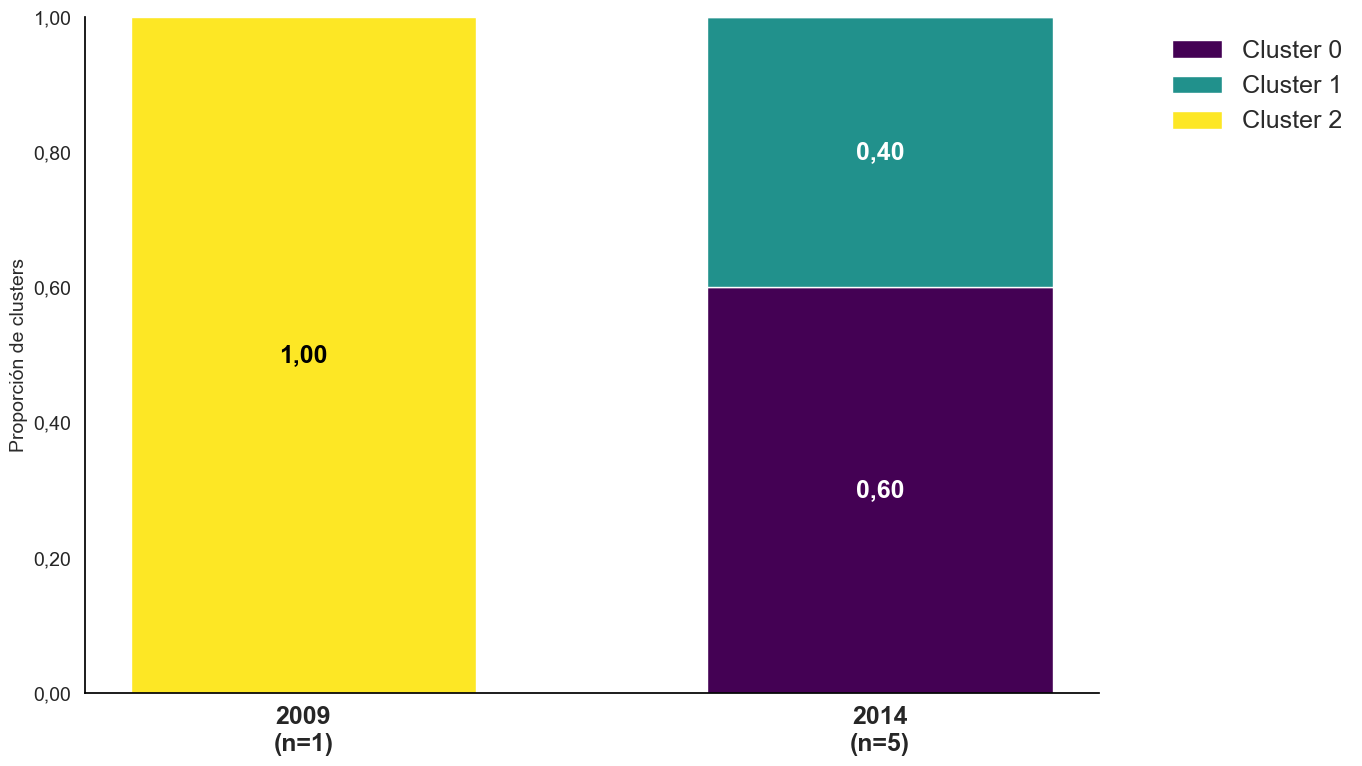

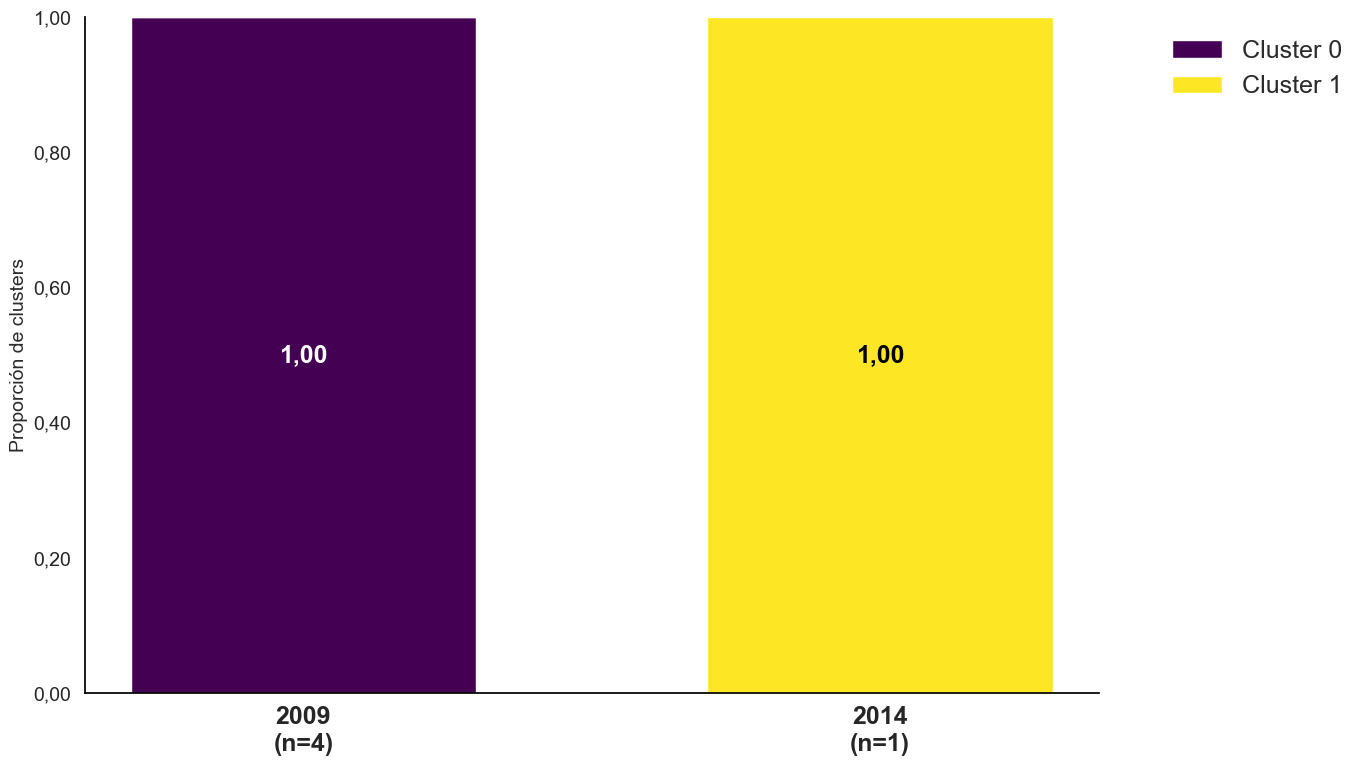

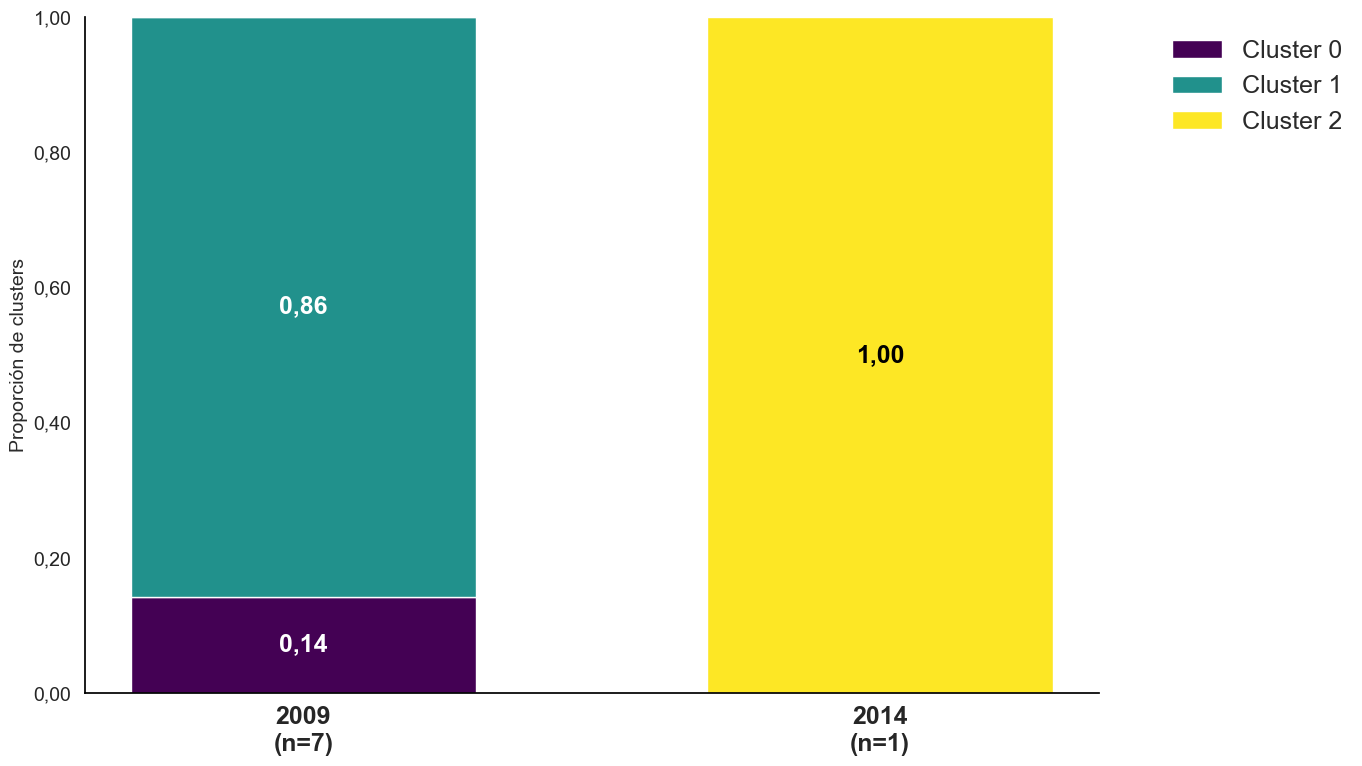

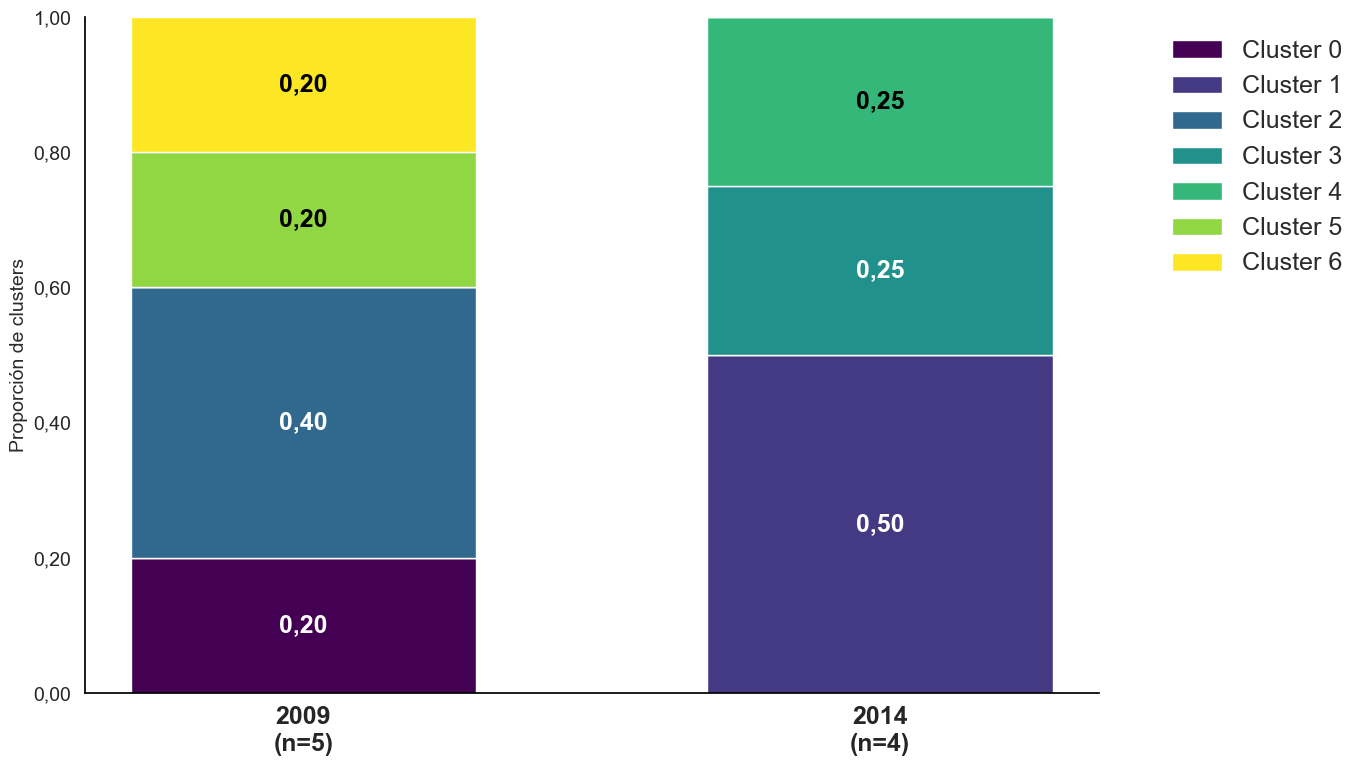

,palabra,periodo,JS_divergence,silhouette_score,cantidad_1,cantidad_2
491,central,2014-2019,0.693147,0.535197,3,7
490,comida,2014-2019,0.693147,0.333333,7,2
488,general,2014-2019,0.693147,0.615385,3,10
288,protector,2014-2019,0.693147,0.465209,1,10
464,perjudicial,2014-2019,0.693147,0.341565,5,3
460,contenido,2014-2019,0.693147,0.595786,9,1
486,activo,2014-2019,0.693147,0.333333,5,1
484,sustancia,2014-2019,0.693147,0.553236,7,9
372,materia,2014-2019,0.693147,0.212304,6,4
377,seguimiento,2014-2019,0.693147,0.298062,10,1


,palabra,periodo,JS_divergence,silhouette_score,cantidad_1,cantidad_2
288,protector,2014-2019,0.693147,0.465209,1,10
491,central,2014-2019,0.693147,0.535197,3,7
488,general,2014-2019,0.693147,0.615385,3,10
546,hijo,2014-2019,0.693147,0.466959,5,4
547,linea,2014-2019,0.693147,0.571429,2,5
542,dependencia,2014-2019,0.693147,0.500000,5,3
335,farmacia,2014-2019,0.693147,0.429582,11,4
543,academia,2014-2019,0.693147,1.000000,2,2
466,consumidor,2014-2019,0.693147,0.507361,3,7
460,contenido,2014-2019,0.693147,0.595786,9,1


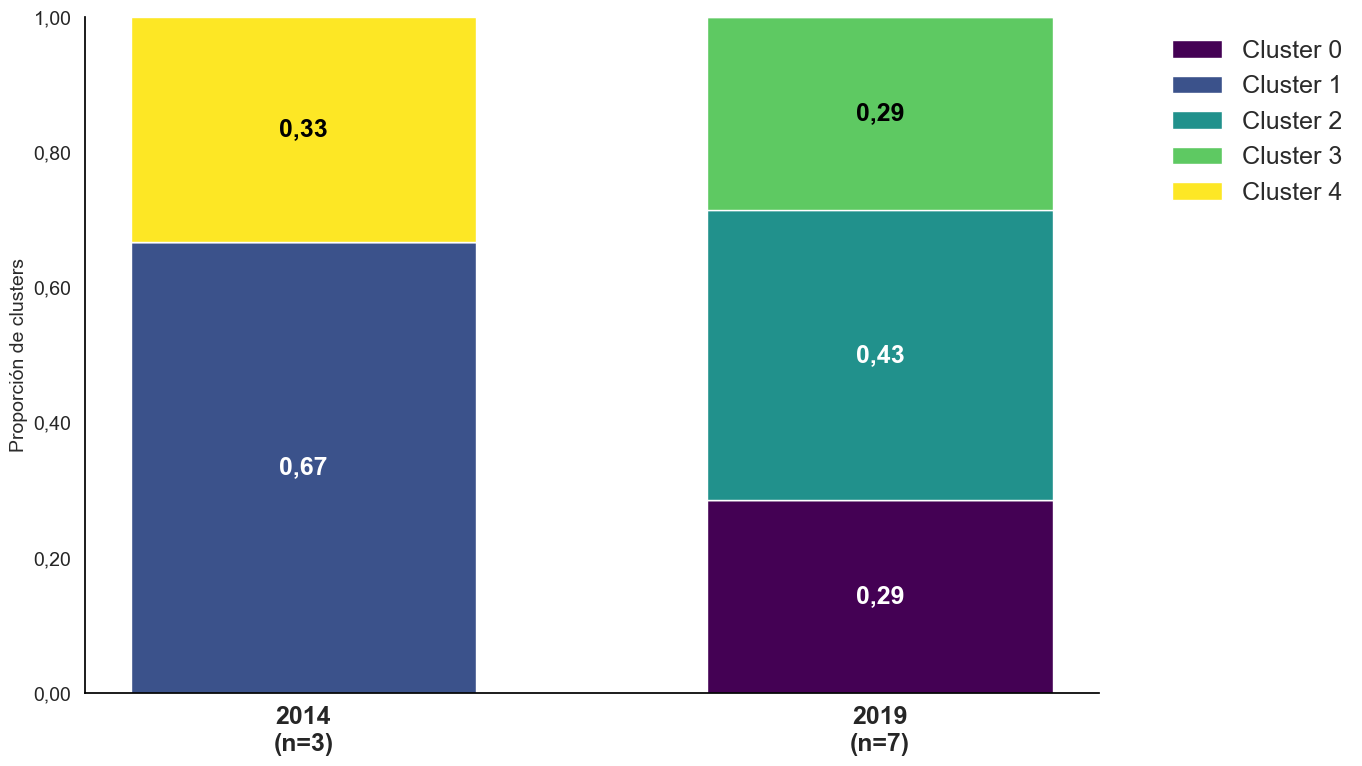

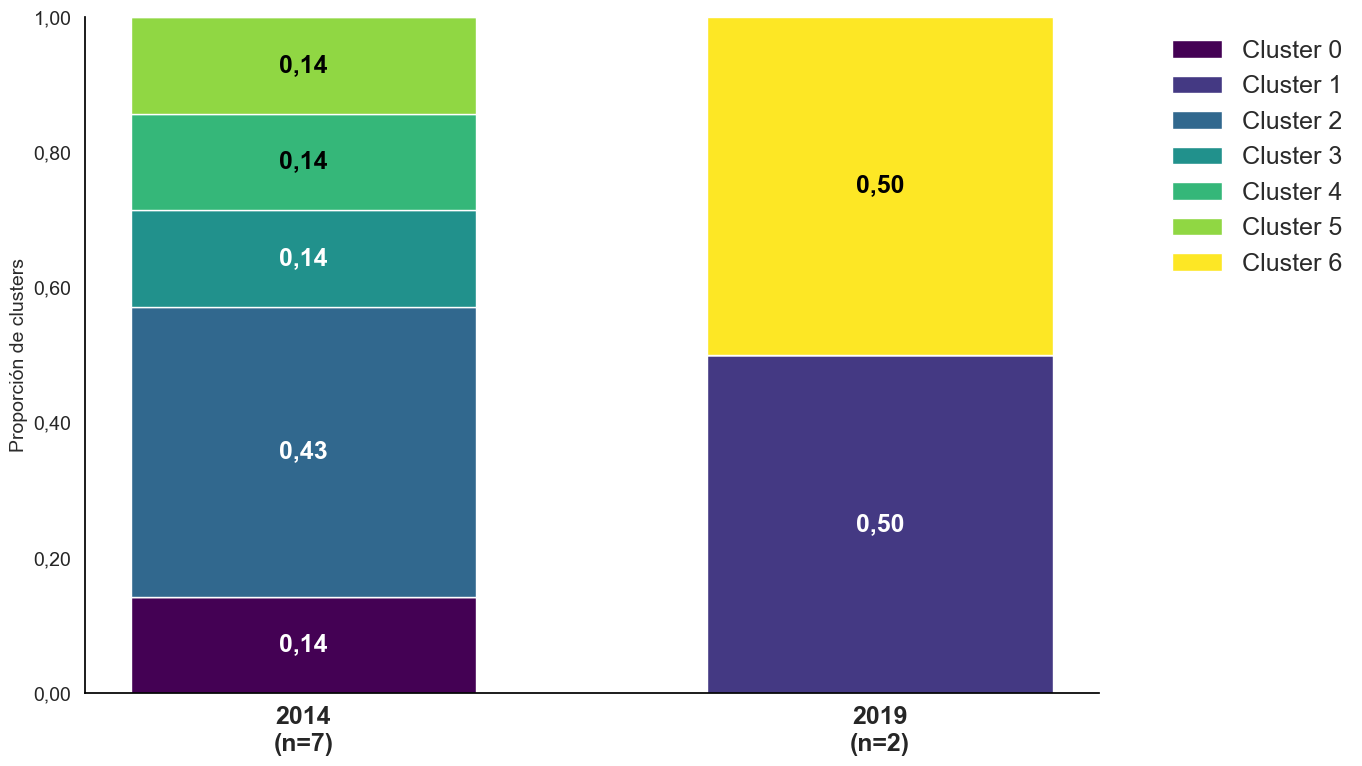

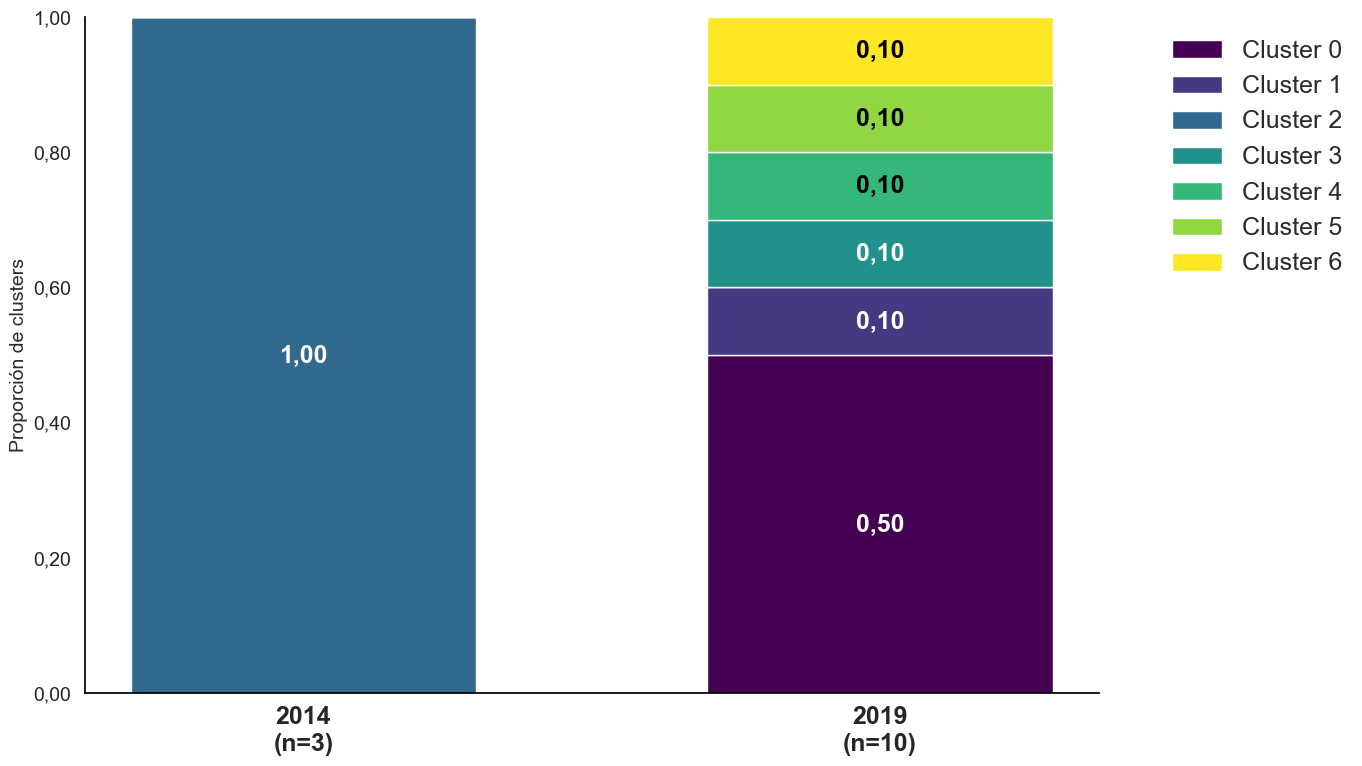

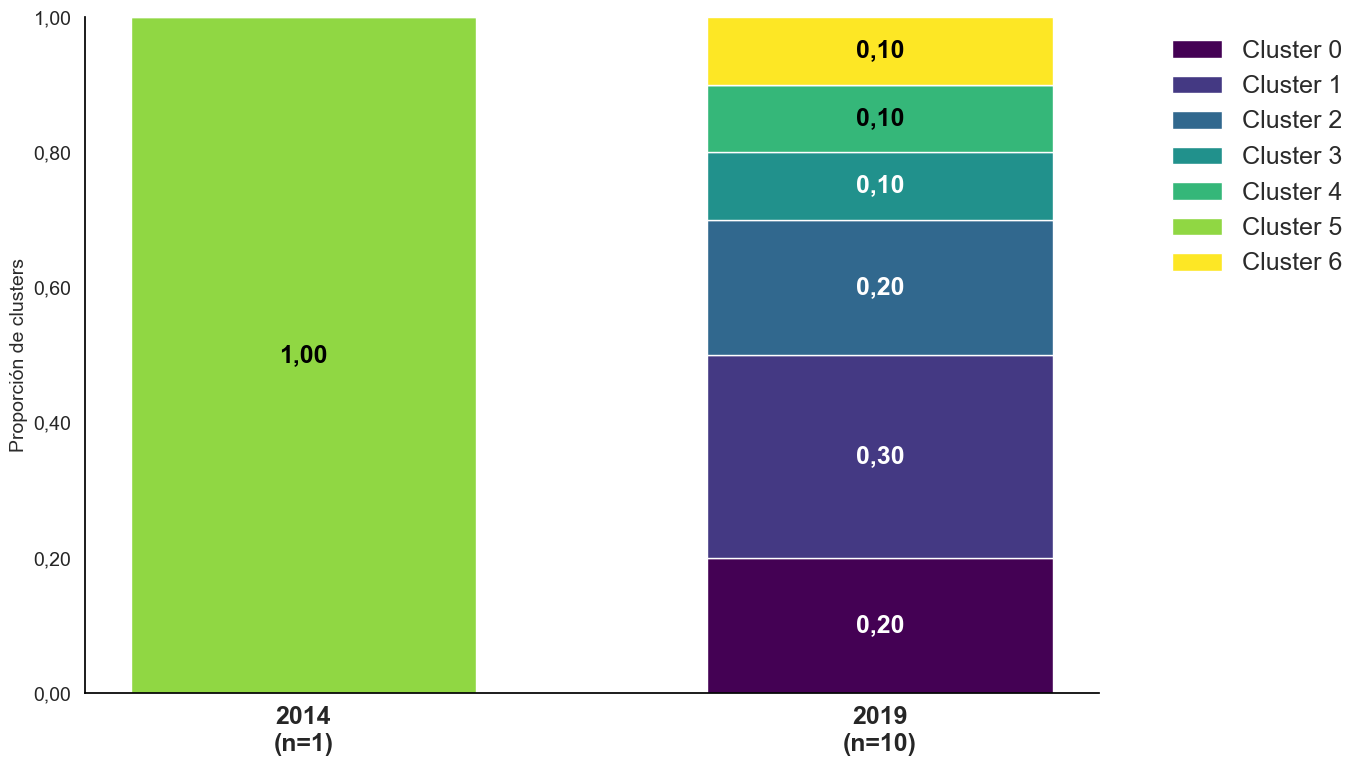

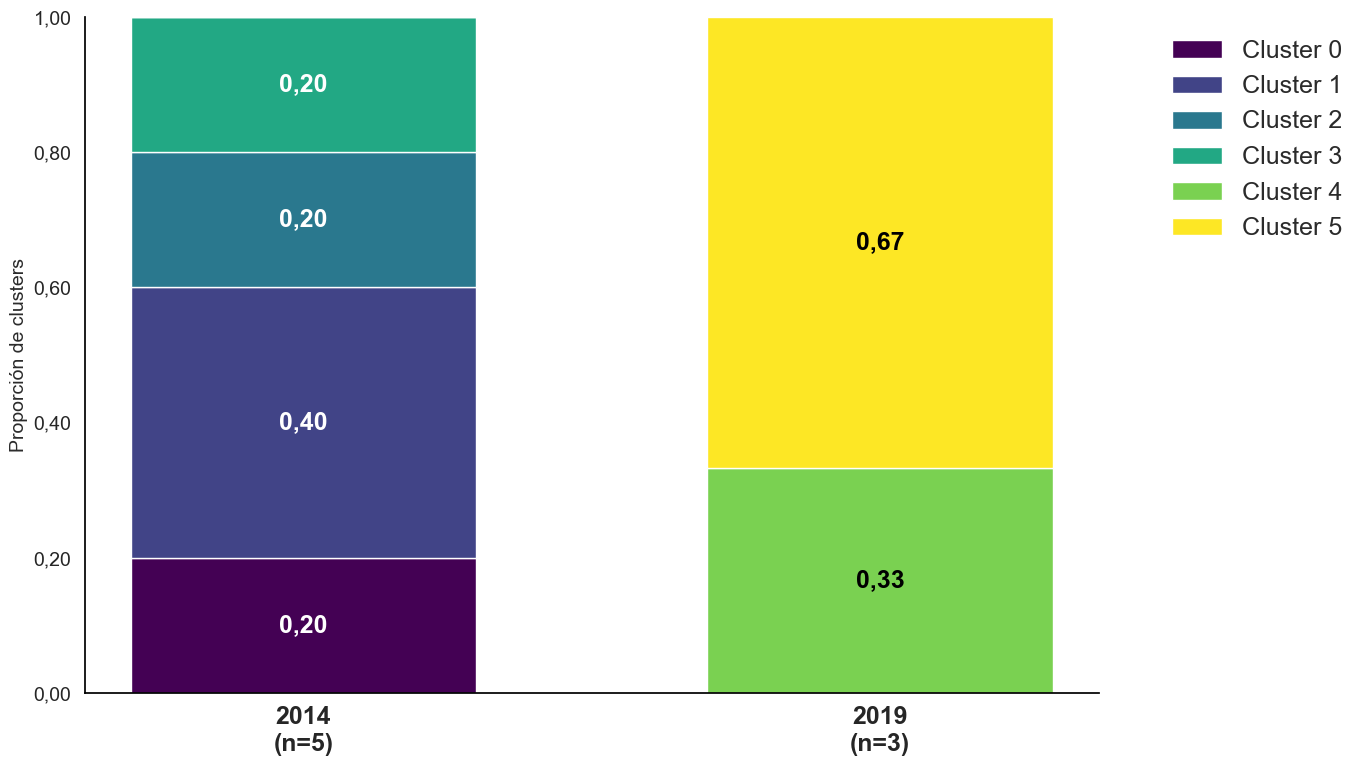

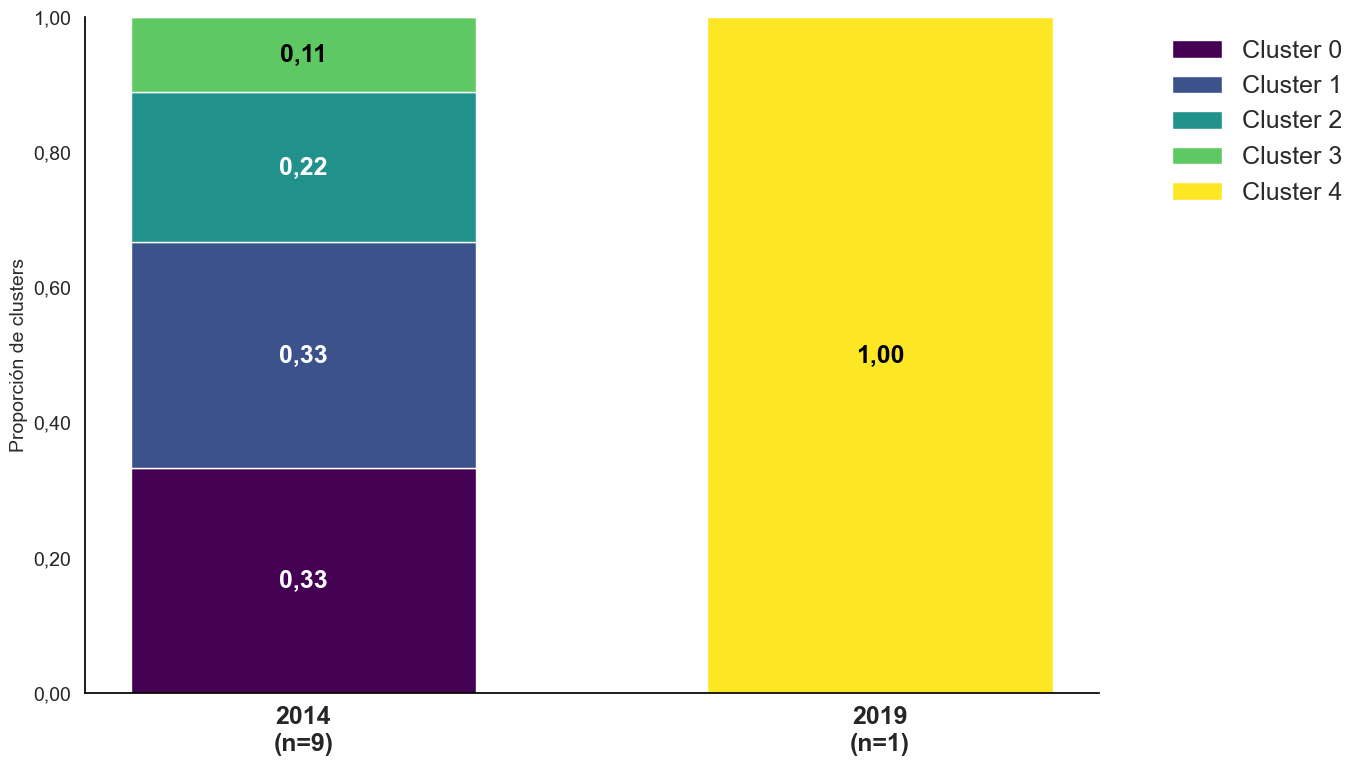

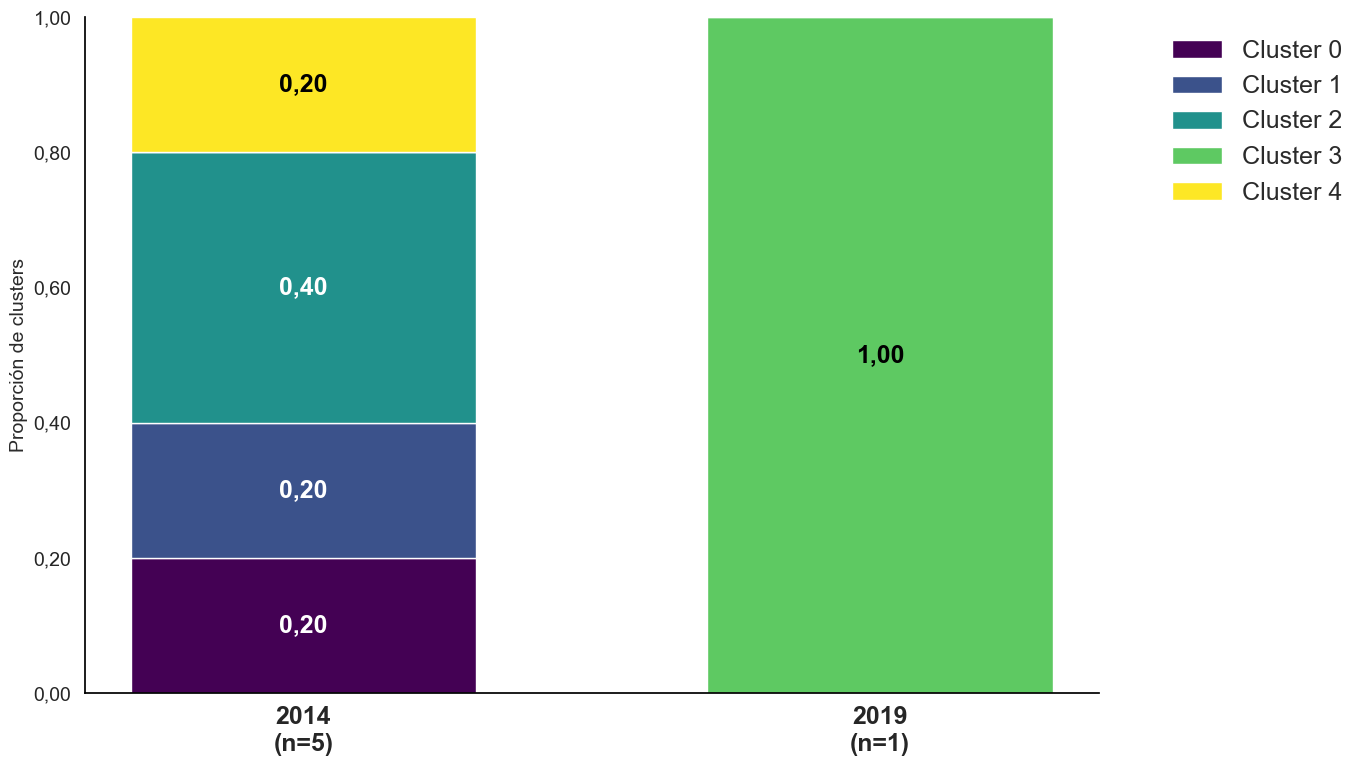

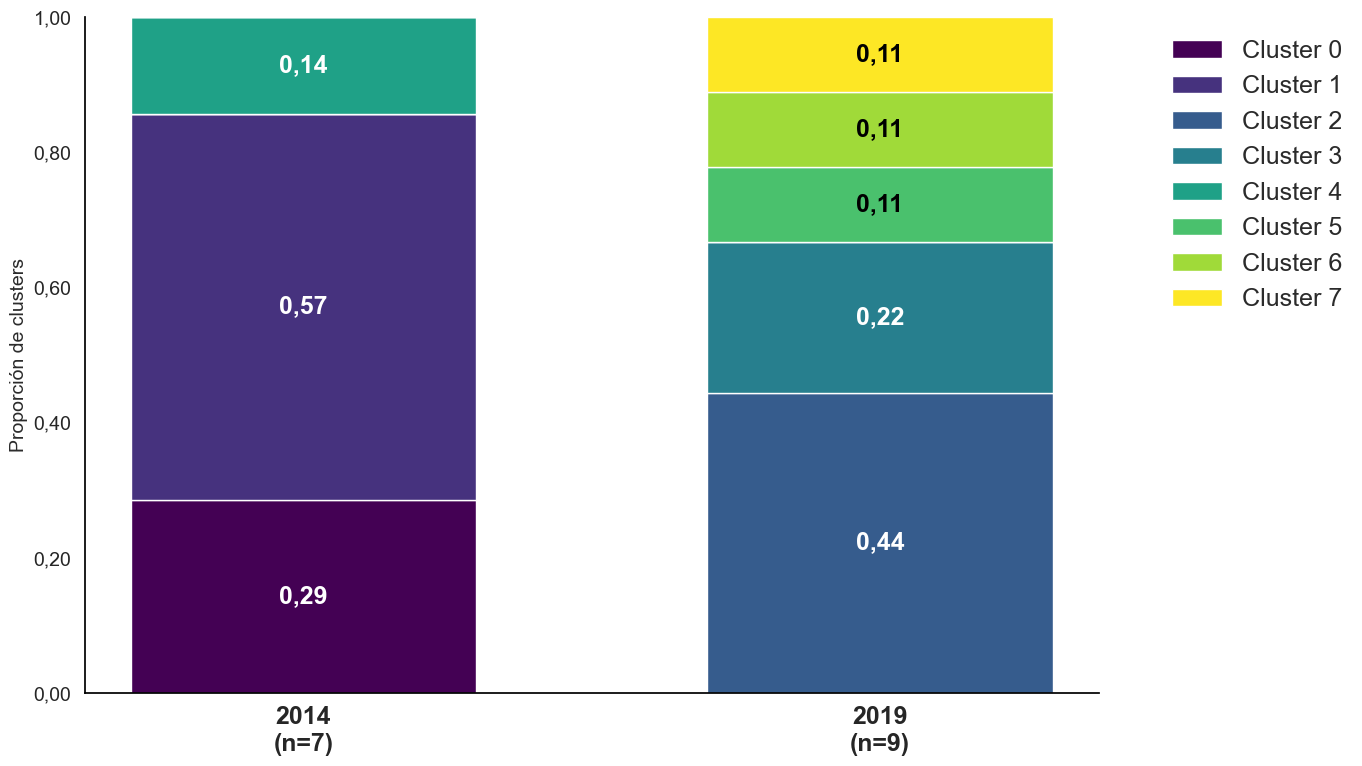

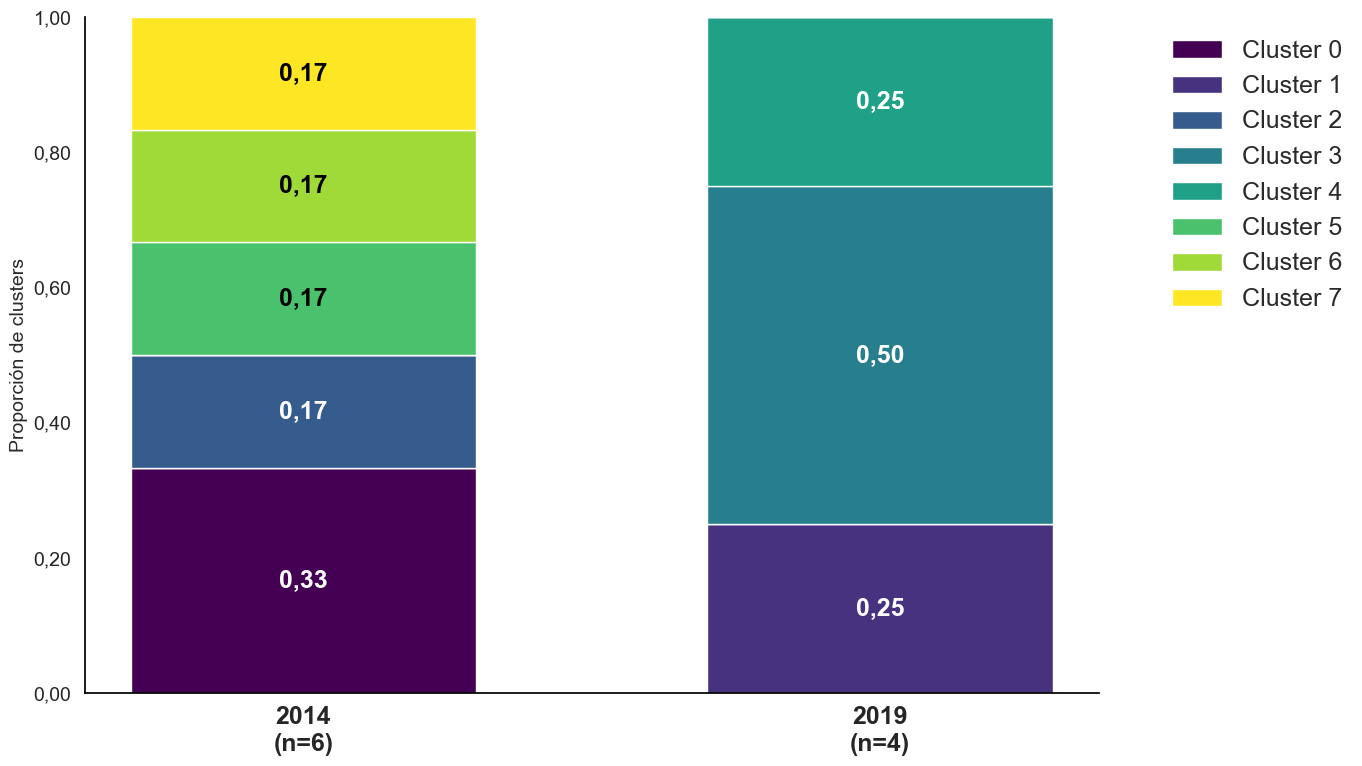

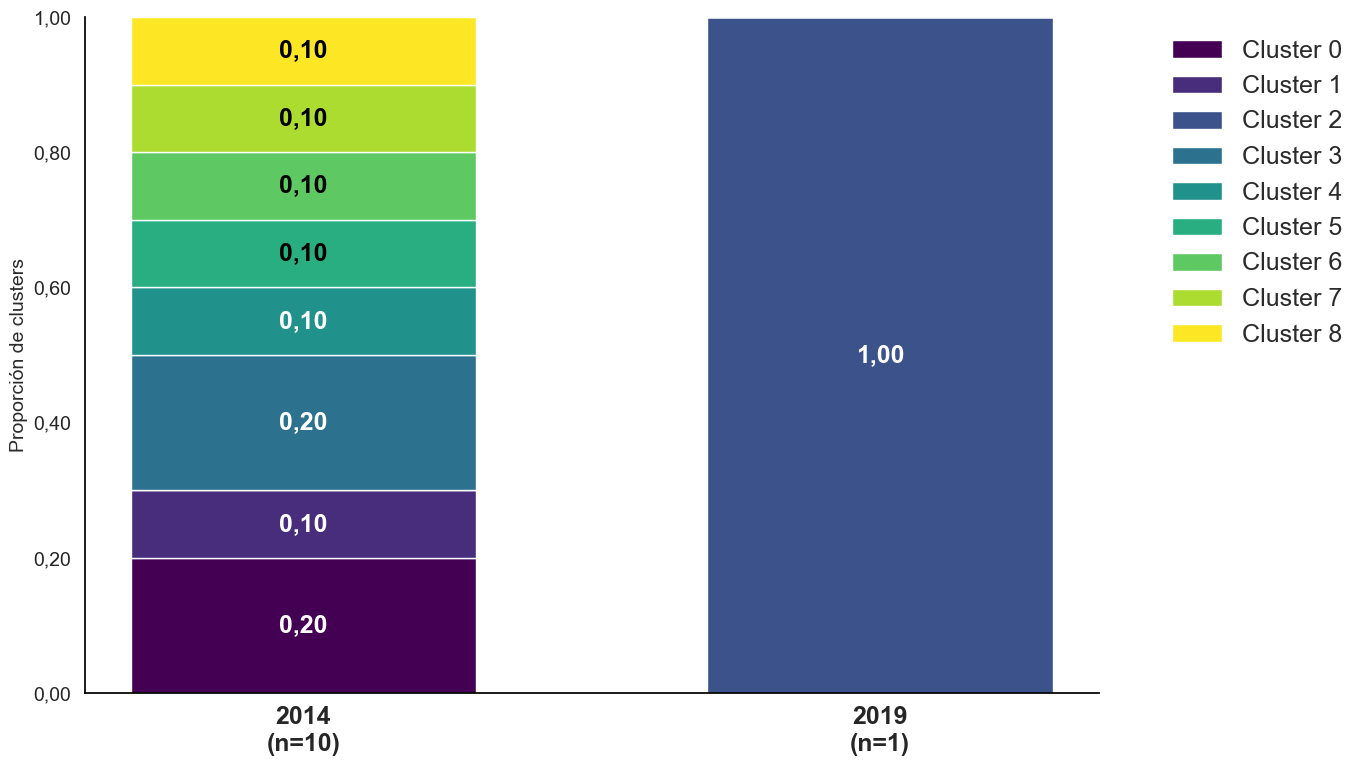

In [14]:
for par_periodo in ['2009-2014', '2014-2019']:
    inicio, fin = map(int, par_periodo.split("-"))
    top10df = df_concat[df_concat['periodo']==par_periodo].sort_values("JS_divergence", ascending=False).head(10)
    display(top10df[["palabra", "periodo","JS_divergence", "silhouette_score","cantidad_1" ,"cantidad_2"]])
    display(df_concat[(df_concat['periodo']==par_periodo) & (df_concat["silhouette_score"] > 0.4)].sort_values("JS_divergence", ascending=False).head(10)[["palabra", "periodo","JS_divergence", "silhouette_score","cantidad_1" ,"cantidad_2"]])
    toppal = list(top10df['palabra'].values)
    toppal_cant1 = list(top10df['cantidad_1'].values)
    toppal_cant2 = list(top10df['cantidad_2'].values)
    embedding_cluster_df =  pd.read_csv(RESULTADOS_DIR+ '/archivos_out/EMBEDDING__Clustering'+str(inicio)+"_"+str(fin)+'.csv')
    for pal,cant1,cant2 in zip(toppal,toppal_cant1,toppal_cant2):
        plot_word_clusters(embedding_cluster_df, inicio, fin, pal,cant1,cant2)

    #embedding_cluster_df.head(4)